In [157]:
LOAD_SIZE = 100

In [158]:
import json
import os
import re

from torch.nn import parallel


folder_path = "../archive/execution_time_history"

def get_data(type):
    target_folder_path = f"{folder_path}/{type}"
    files = os.listdir(target_folder_path)
    datas = {}
    for f in files:
        if not "json" in f:
            continue

        pattern = rf"{type}-batch_size-(\d+)-k-(\d+)\.json"
        match = re.match(pattern, f)
        bsz = int(match.group(1))
        k = int(match.group(2))
        effective_bsz = int(LOAD_SIZE / bsz)

        fp = open(f"{target_folder_path}/{f}")
        data = json.load(fp)
        fp.close()

        raw = data["raw"]
        encoder_times = raw["ENCODER_TIMER"][:effective_bsz]
        decoder_total_times = raw["DECODER_GENERATION_TIMER"][:effective_bsz]
        raw_decoder_times = raw["DECODER_TIMER"]

        decoder_first_token_times = []
        decoder_times = []
        # collect decoder runtime
        curr_idx = 0
        for total_time in decoder_total_times:
            is_first = True
            thresold = 0
            while total_time > thresold and curr_idx < len(raw_decoder_times):
                t = raw_decoder_times[curr_idx]
                curr_idx += 1
                total_time -= t
                if is_first:
                    decoder_first_token_times.append(t)
                    is_first = False
                else:
                    decoder_times.append(t)
                    thresold = t

        if not bsz in datas:
            datas[bsz] = {} 
        datas[bsz][k] = {
            "ENCDOER_TIMER_CLEAR": encoder_times,
            "DECODER_TIMER_CLEAR": decoder_times,
            "DECODER_GENERATION_TIMER_CLEAR": decoder_total_times,
            "DECODER_TIMER_FIRST": decoder_first_token_times,
        }
                    
    return datas

In [ ]:
from copy import deepcopy
from matplotlib.axes import Axes
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np


def plot(datas):
    _datas = deepcopy(datas)
    for bsz in datas:
        for k in datas[bsz]:
            data = datas[bsz][k]
            _data = {k: np.array(v).mean() for k, v in data.items()}
            _datas[bsz][k] = _data

    datas = _datas

    fig, axes = plt.subplots(1, 3, figsize=(16, 4), dpi=200)
    ax: Axes
    for ax, type in zip(
        axes.flatten(),
        [
            "ENCDOER_TIMER_CLEAR",
            "DECODER_TIMER_CLEAR",
            "DECODER_TIMER_FIRST",
            # "DECODER_GENERATION_TIMER_CLEAR",
        ],
    ):
        # for bsz in sorted(datas.keys(), reverse=True):
        for bsz in [1, 16, 32]:
            x = []
            y = []
            for k in sorted(np.linspace(4, 16, 13, dtype=int), reverse=True):
                if bsz in datas and k in datas[bsz]:
                    x.append(k)
                    y.append(datas[bsz][k][type])
            # y = np.array(y)
            # y = (y - y.min()) / (y.max() - y.min())
            ax.plot(x, y, label=bsz)
            ax.scatter(x, y)
        ax.set_title(type)
        ax.set_xlabel("x")
        ax.set_xticks(x)
    axes.flatten()[0].set_ylabel("runtime")
    plt.legend()

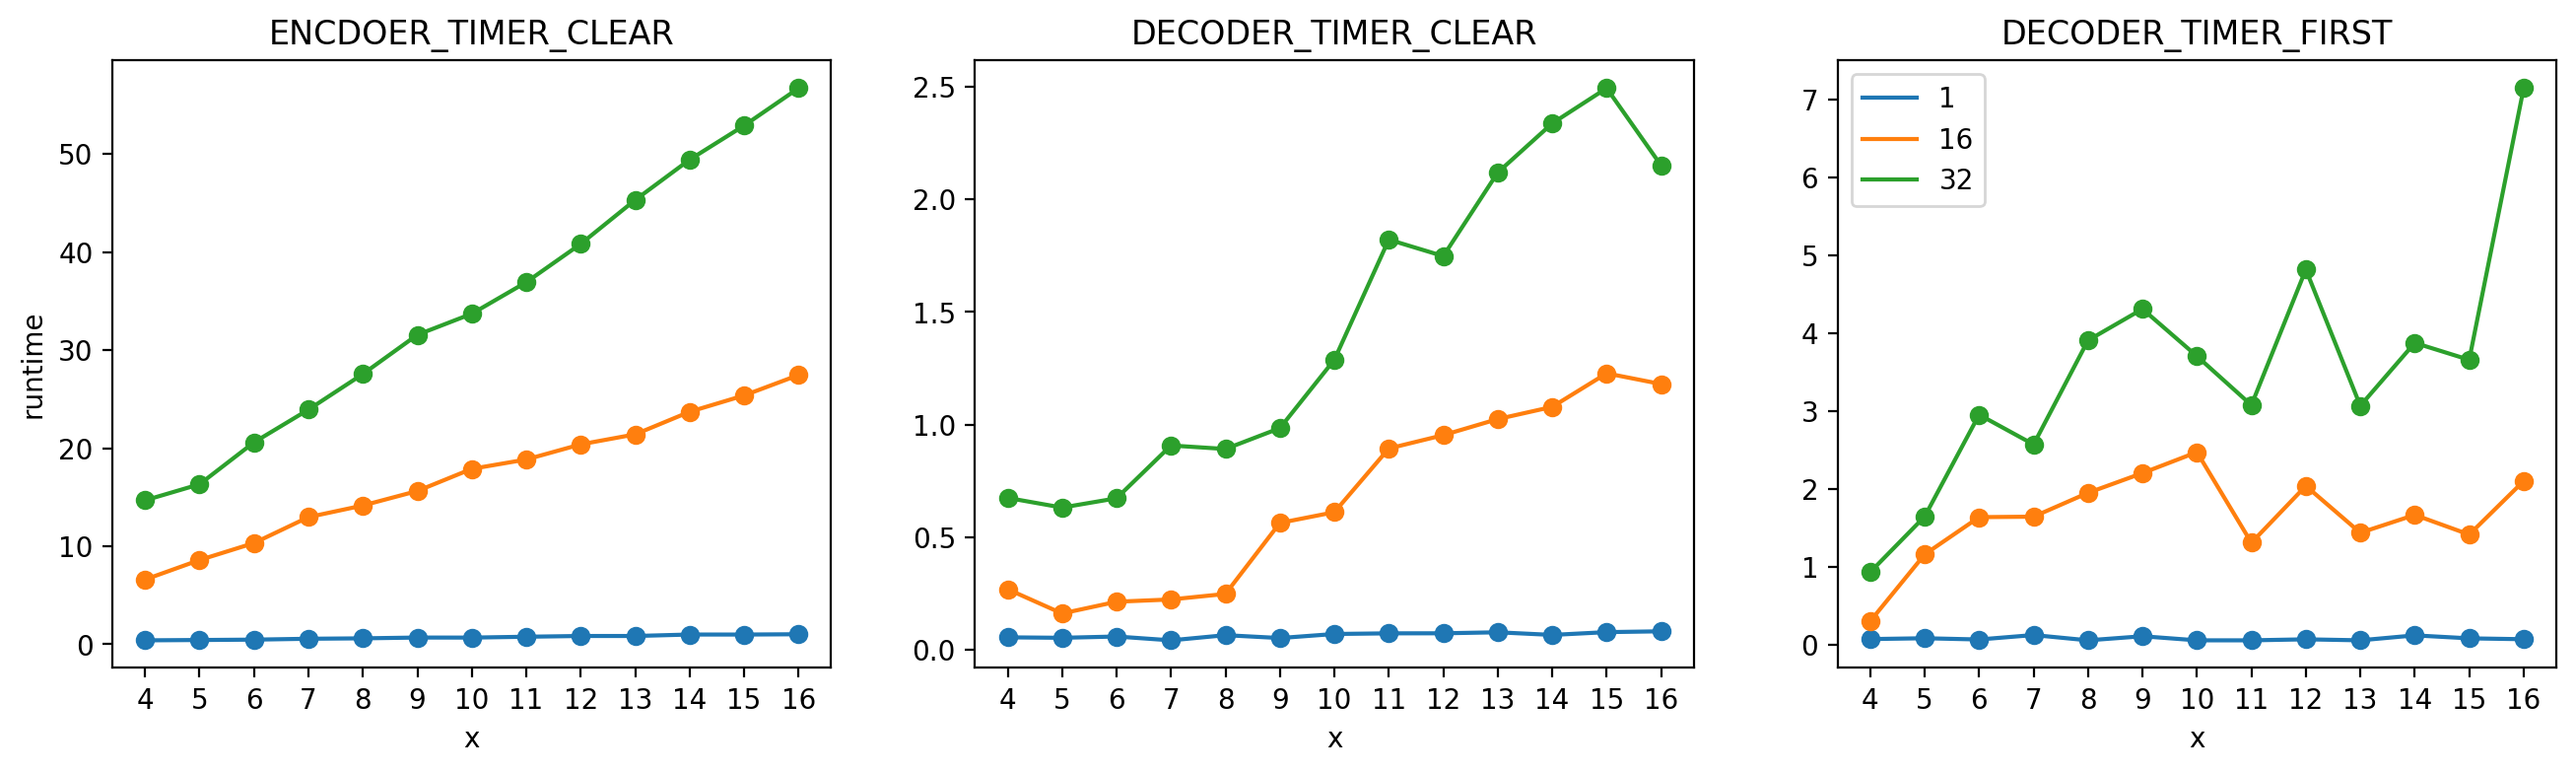

In [160]:
cpu_time_history = get_data("cpu")
plot(cpu_time_history)

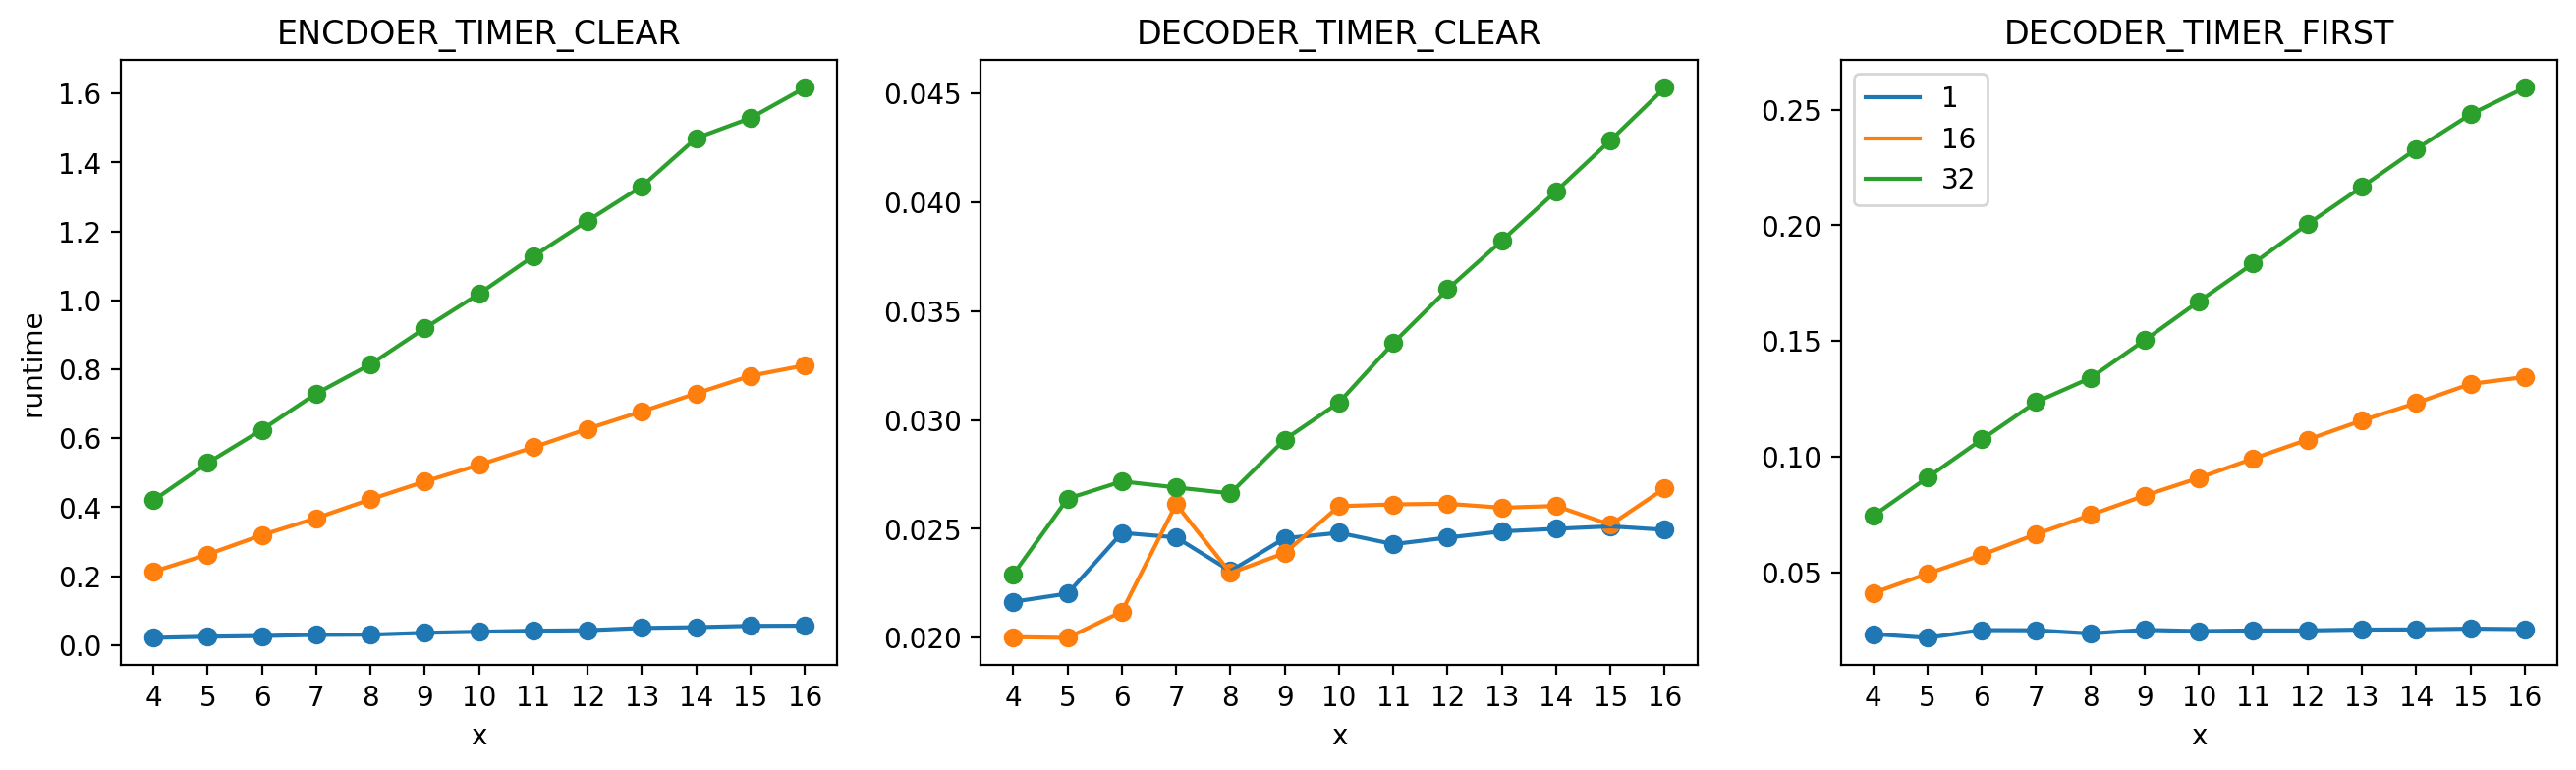

In [161]:
gpu_time_history = get_data("gpu")
plot(gpu_time_history)